# Analysis Results

## 1D-Ising Chain

### $\tau$ hyperparameter

#### F-CRAB case

##### Data

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

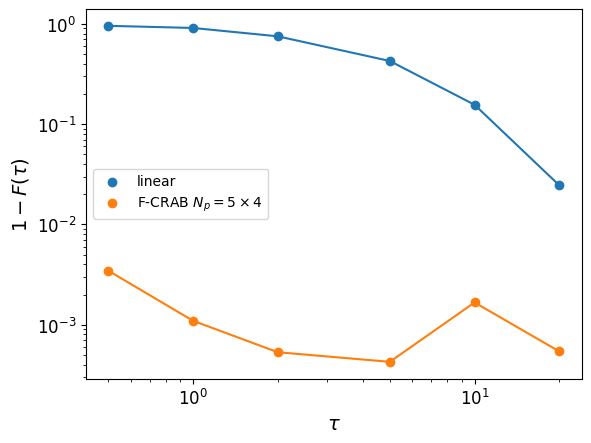

In [2]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus, 1 - np.asarray(fidelities_opt), label=r"F-CRAB $N_p=5 \times 4$", color="C1"
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

##### Losses

[-0.8804029447625693, -1.4260674555887938, -2.00640010125504, -2.5720786050168725, -2.791375093967228, -2.9704987988783955, -3.2795727951482467, -3.573310746926034, -3.823885668825562, -4.373527794993027, -4.648266129693926, -4.919184150662309, -5.001863251737222, -5.069364099694924, -5.2127282580091805, -5.354302258685687, -5.481913616785891, -5.584867129468939, -5.670071997190844, -5.679783114678931, -5.6903557814840315, -5.719396473765049, -5.737683634332196, -5.760826693395265, -5.780143630824945, -5.803362367883634, -5.83347368658336, -5.8706607761073775, -5.896472758878025, -5.919290372187072, -5.923992965701516, -5.936296236945005, -5.941595774166529, -5.953346119267187, -5.961332724468282, -5.968676241591428, -5.972000321430145, -5.97252802201323, -5.972870057663839, -5.974608492092237, -5.976490634697706, -5.979674869428492, -5.980951667175825, -5.981623787631165, -5.982028197749256, -5.982308705360454, -5.9834052938811615, -5.984306955688536, -5.9845229711612005, -5.984696977

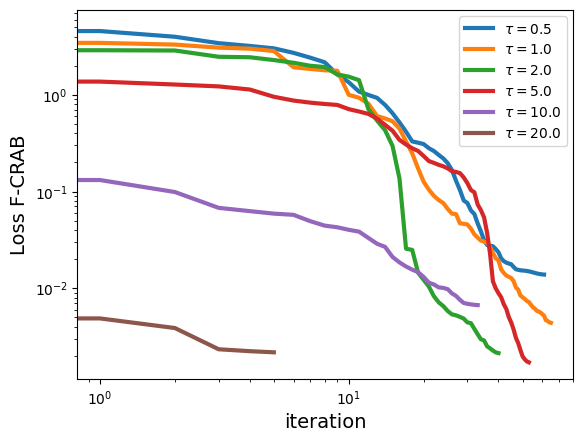

In [6]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss F-CRAB", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

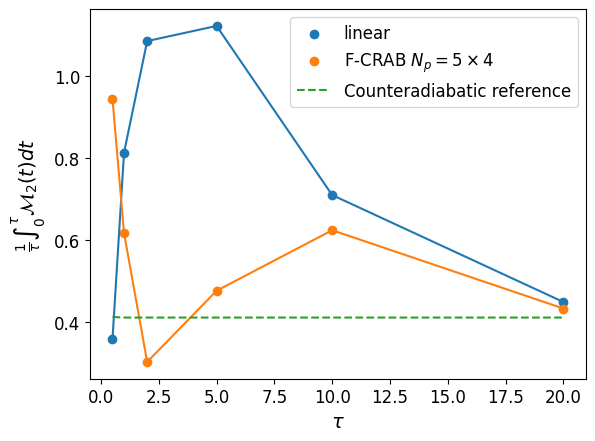

In [23]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

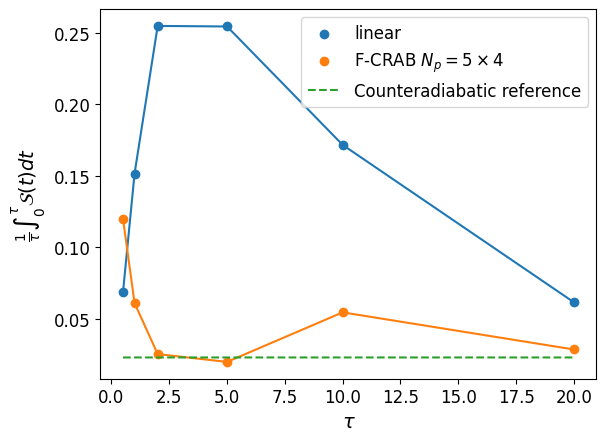

In [7]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

#### Fourier Case

##### Data

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5_fourier.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

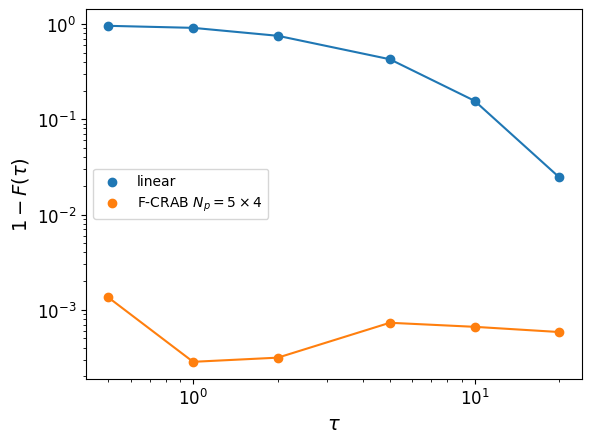

In [2]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus, 1 - np.asarray(fidelities_opt), label=r"F-CRAB $N_p=5 \times 4$", color="C1"
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

Analysis of the probs for a fixed $\tau$

(20,)


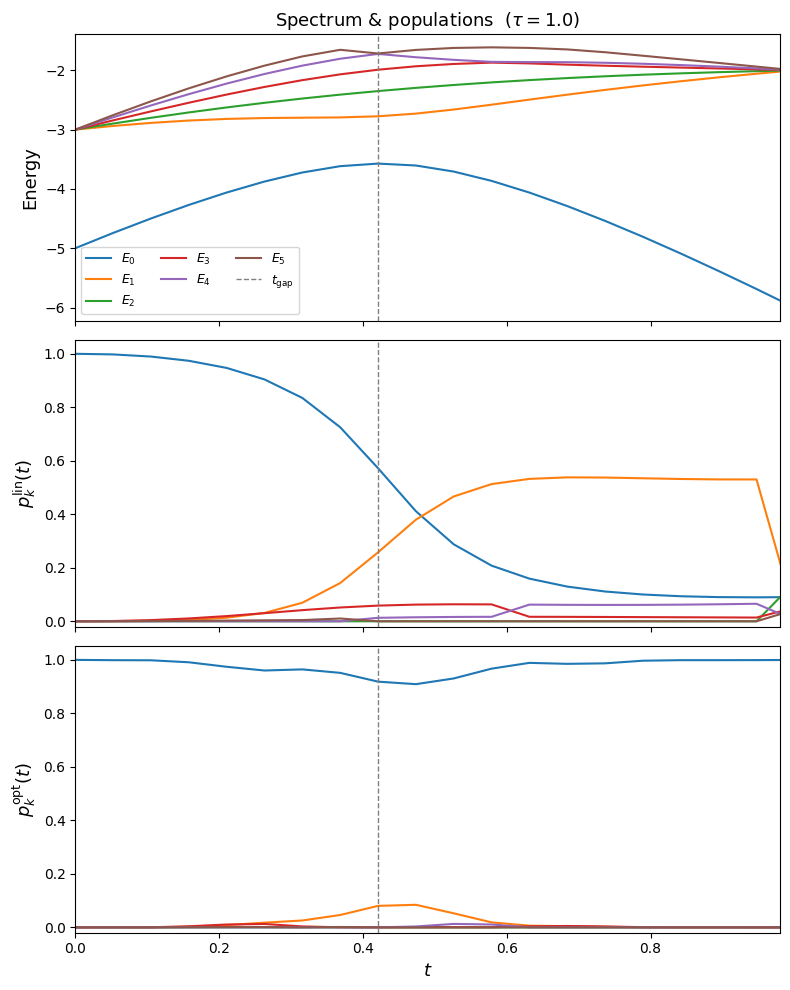

In [13]:
import numpy as np
import matplotlib.pyplot as plt

idx_tau = 1

r = results[idx_tau]  # pick your tau
time = r["time"]

print(time.shape)
spectrum = r["spectrum"]  # (time_steps, nlevels)
probs_lin = r["probs_lin"]  # (time_steps, nlevels)
probs_opt = r["probs_opt"]  # (time_steps, nlevels)
t_gap = r["t_min_gap"]
nlevels = spectrum.shape[1]  # 6

colors = [f"C{k}" for k in range(nlevels)]
labels = [r"$E_0$", r"$E_1$", r"$E_2$", r"$E_3$", r"$E_4$", r"$E_5$"]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# ── top: energy spectrum ───────────────────────────────────────────────────────
ax = axes[0]
for k in range(nlevels):
    ax.plot(
        time / taus[idx_tau], spectrum[:, k], color=colors[k], lw=1.5, label=labels[k]
    )
ax.axvline(t_gap / taus[idx_tau], color="gray", ls="--", lw=1, label=r"$t_{\rm gap}$")
ax.set_ylabel("Energy", fontsize=13)
ax.legend(ncol=3, fontsize=9)
ax.set_title(rf"Spectrum & populations  ($\tau={r['tau']:.1f}$)", fontsize=13)
ax.set_xlim([0, 0.98])
# ── middle: populations — linear ───────────────────────────────────────────────
ax = axes[1]
for k in range(nlevels):
    ax.plot(
        time / taus[idx_tau], probs_lin[:, k], color=colors[k], lw=1.5, label=labels[k]
    )
ax.axvline(t_gap / taus[idx_tau], color="gray", ls="--", lw=1)
ax.set_ylabel(r"$p_k^{\rm lin}(t)$", fontsize=13)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim([0, 0.98])
# ── bottom: populations — optimal control ──────────────────────────────────────
ax = axes[2]
for k in range(nlevels):
    ax.plot(
        (time) / taus[idx_tau],
        probs_opt[:, k],
        color=colors[k],
        lw=1.5,
        label=labels[k],
    )
ax.axvline(t_gap / taus[idx_tau], color="gray", ls="--", lw=1)
ax.set_ylabel(r"$p_k^{\rm opt}(t)$", fontsize=13)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(r"$t$", fontsize=13)
ax.set_xlim([0, 0.98])
plt.tight_layout()
plt.show()

Comparison with all the $\tau$

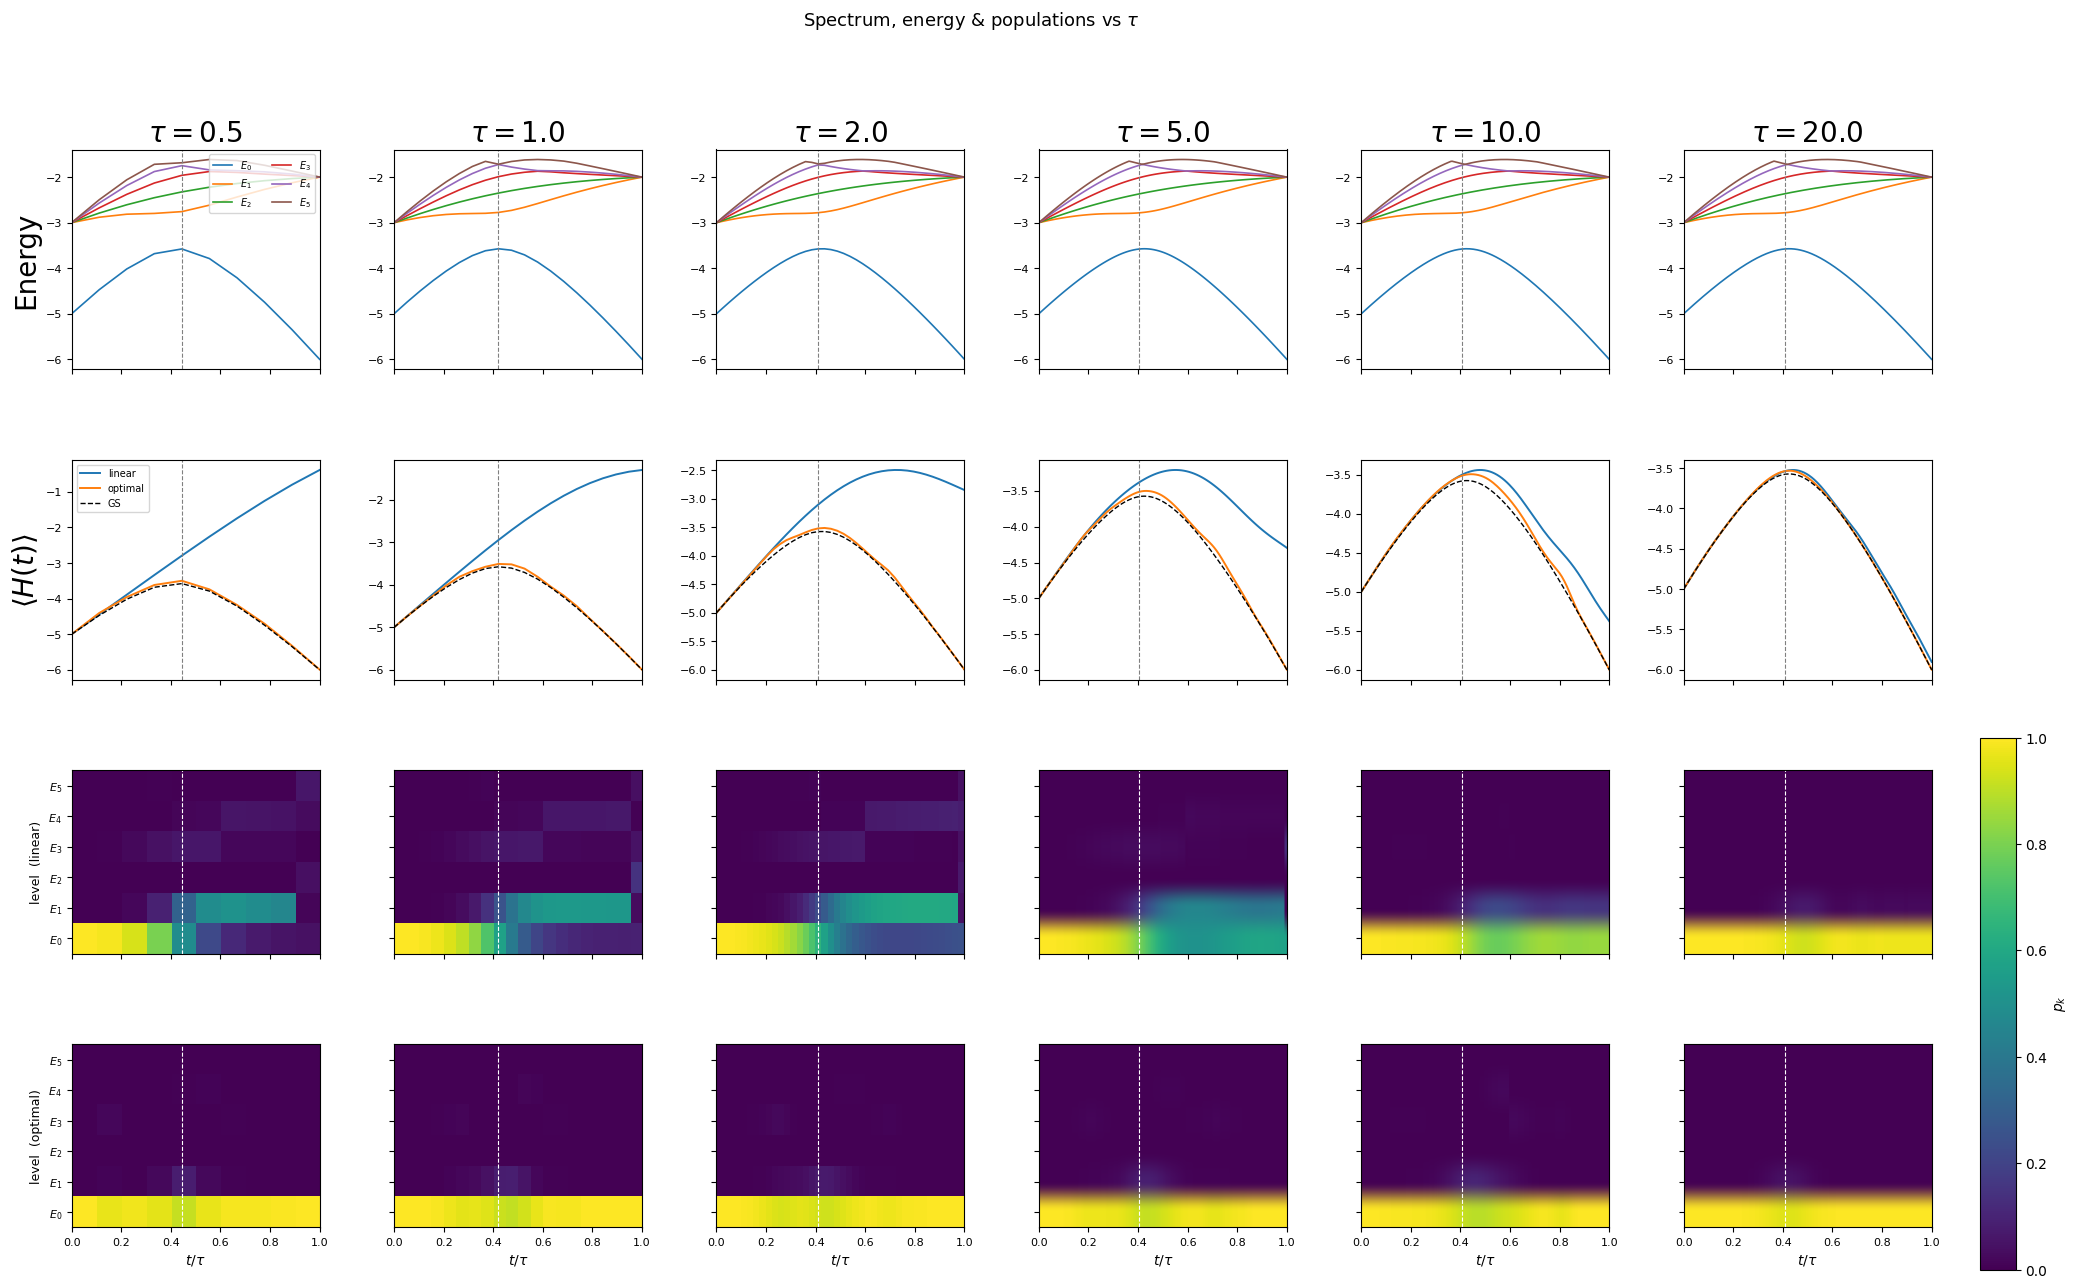

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── config ────────────────────────────────────────────────────────────────────
nlevels = results[0]["spectrum"].shape[1]
colors = [f"C{k}" for k in range(nlevels)]
labels = [rf"$E_{k}$" for k in range(nlevels)]
n_taus = len(results)

# ── figure layout ─────────────────────────────────────────────────────────────
# Top row: spectrum + energy(t) for one representative tau
# Bottom rows: heatmaps p_k(t/tau) for lin and opt, one column per tau
fig = plt.figure(figsize=(4 * n_taus, 14))
gs = gridspec.GridSpec(
    4, n_taus, height_ratios=[1.2, 1.2, 1, 1], hspace=0.45, wspace=0.3
)

# ── row 0: energy spectrum (one per tau) ─────────────────────────────────────
for j, (r, tau) in enumerate(zip(results, taus)):
    ax = fig.add_subplot(gs[0, j])
    t = r["time"] / tau
    for k in range(nlevels):
        ax.plot(
            t,
            r["spectrum"][:, k],
            color=colors[k],
            lw=1.2,
            label=labels[k] if j == 0 else None,
        )
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_title(rf"$\tau={tau:.1f}$", fontsize=20)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel("Energy", fontsize=20)
        ax.legend(ncol=2, fontsize=7, loc="upper right")
    ax.tick_params(labelsize=8)
    ax.set_xticklabels([])

# ── row 1: energy E(t) = <psi|H(t)|psi> for lin and opt ─────────────────────
for j, (r, tau) in enumerate(zip(results, taus)):
    ax = fig.add_subplot(gs[1, j])
    t = r["time"] / tau
    e0 = r["spectrum"][:, 0]  # instantaneous GS energy
    ax.plot(t, r["energy_lin"], color="C0", lw=1.4, label="linear")
    ax.plot(t, r["energy_opt"], color="C1", lw=1.4, label="optimal")
    ax.plot(t, e0, color="k", lw=1, ls="--", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\langle H(t)\rangle$", fontsize=20)
        ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
    ax.set_xticklabels([])

# ── rows 2-3: heatmaps of p_k(t/tau) ─────────────────────────────────────────
for row_idx, (proto_key, proto_label) in enumerate(
    [("probs_lin", "linear"), ("probs_opt", "optimal")], start=2
):
    for j, (r, tau) in enumerate(zip(results, taus)):
        ax = fig.add_subplot(gs[row_idx, j])
        probs = r[proto_key].T  # (nlevels, time_steps)
        t = r["time"] / tau

        im = ax.imshow(
            probs,
            aspect="auto",
            origin="lower",
            extent=[t[0], t[-1], -0.5, nlevels - 0.5],
            vmin=0,
            vmax=1,
            cmap="viridis",
        )
        ax.axvline(r["t_min_gap"] / tau, color="white", ls="--", lw=0.8)
        ax.set_yticks(range(nlevels))
        ax.set_xlim(0, 1)
        if j == 0:
            ax.set_yticklabels([rf"$E_{k}$" for k in range(nlevels)], fontsize=8)
            ax.set_ylabel(f"level  ({proto_label})", fontsize=9)
        else:
            ax.set_yticklabels([])
        if row_idx == 3:
            ax.set_xlabel(r"$t/\tau$", fontsize=10)
        else:
            ax.set_xticklabels([])
        ax.tick_params(labelsize=8)

# shared colorbar for heatmaps
cbar_ax = fig.add_axes([0.92, 0.08, 0.015, 0.38])
fig.colorbar(
    ScalarMappable(norm=Normalize(0, 1), cmap="viridis"), cax=cbar_ax, label=r"$p_k$"
)

plt.suptitle("Spectrum, energy & populations vs $\\tau$", fontsize=13, y=0.98)
plt.savefig("spectrum_probs_vs_tau.pdf", bbox_inches="tight")
plt.show()

##### Losses

[-2.727901992666872, -2.8137854105975, -2.996778419140895, -3.05292786150202, -3.248785073089777, -3.87365013908398, -4.008931191711631, -4.327493302434131, -4.6913341181291495, -4.790719603379585, -4.945054688194624, -5.156448029691762, -5.4220683849877975, -5.478446841128614, -5.528805206210005, -5.603771842334246, -5.681062812071324, -5.800806923052803, -5.847643207880349, -5.895447368627547, -5.9034906826851925, -5.909080363840242, -5.918075798767595, -5.930375535569947, -5.938323839613876, -5.945915054042376, -5.948556340766278, -5.955501167759187, -5.965049644021493, -5.975881616917105, -5.979118263175811, -5.982745081851207, -5.985257245887715, -5.987749454420745, -5.990596296921695, -5.992338397807266, -5.99286324769847, -5.993047013974867, -5.993456574092798, -5.993877524713561, -5.99437565926142, -5.994571159516115, -5.994612865855845]
[-2.6631303266929325, -2.863497629768955, -2.956630909973114, -3.196233672201224, -3.3840585348929726, -3.5431070525374744, -3.969286783563518

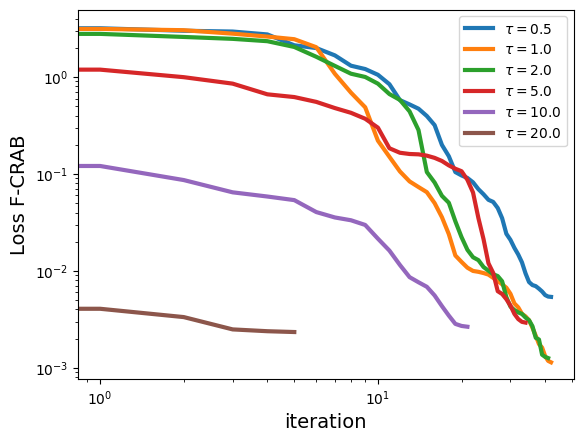

In [3]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss F-CRAB", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

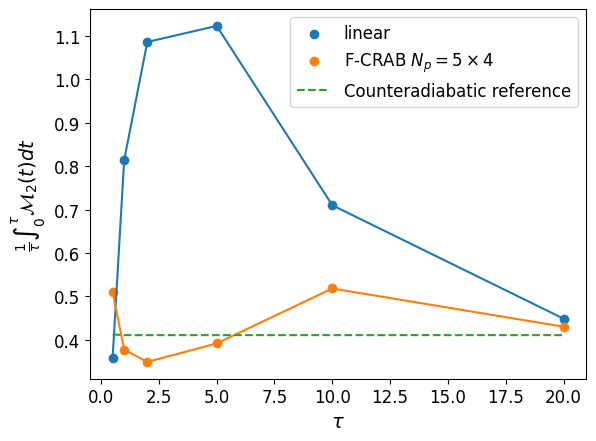

In [4]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

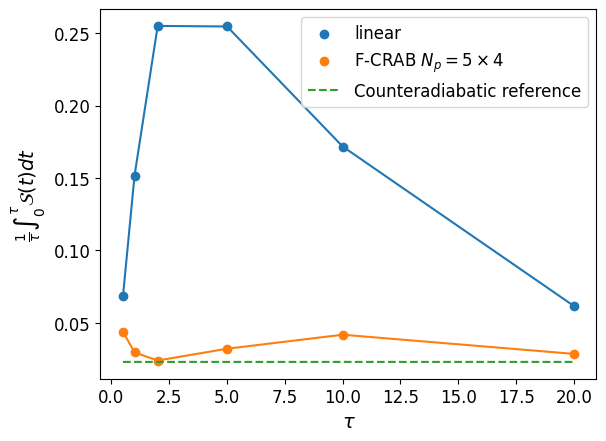

In [5]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

#### SoftPlus + Fourier case

##### Data

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5_positive fourier.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

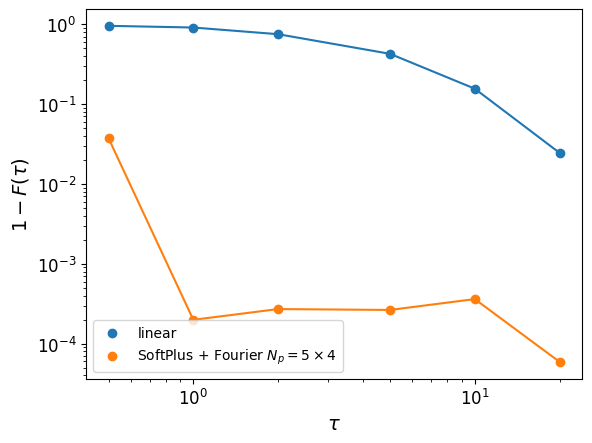

In [11]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus,
    1 - np.asarray(fidelities_opt),
    label=r"SoftPlus + Fourier $N_p=5 \times 4$",
    color="C1",
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

##### Losses

[-2.8110318032375208, -2.8898391559641743, -2.93493125258016, -3.050618059574512, -3.106940536114735, -3.1733480775223435, -3.2893548378916284, -3.5601059469228686, -4.070826042476574, -4.836932721703132, -5.250133089228747, -5.37488309531815, -5.468856425605605, -5.579660923146513, -5.6766011793538595, -5.719262283199554, -5.741192242198411, -5.778658996196345, -5.820400566676487, -5.834833622542545, -5.839893690412584, -5.842883681924038, -5.844707326753715, -5.845117738015818, -5.845362762579752, -5.8462649090265435, -5.847200489448455, -5.847341187598993, -5.847593743302007, -5.847683521603551, -5.847748724398588, -5.847975349770664, -5.8485050756669805, -5.8489267573276145, -5.849200016872027, -5.849574956480269, -5.8496585445771325, -5.849815754373687]
[-2.8863793591540614, -2.9484377034019214, -3.201578973829773, -3.2495064285622948, -3.5540946673408884, -3.8952313907072376, -4.077946180152375, -4.446918612554835, -5.288268152199236, -5.560888465035385, -5.738973943510565, -5.82

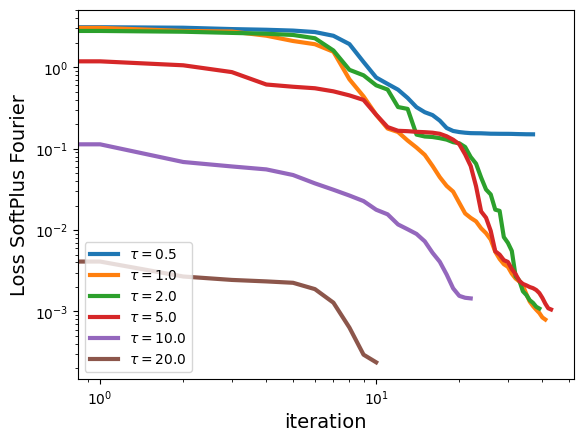

In [12]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss SoftPlus Fourier", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

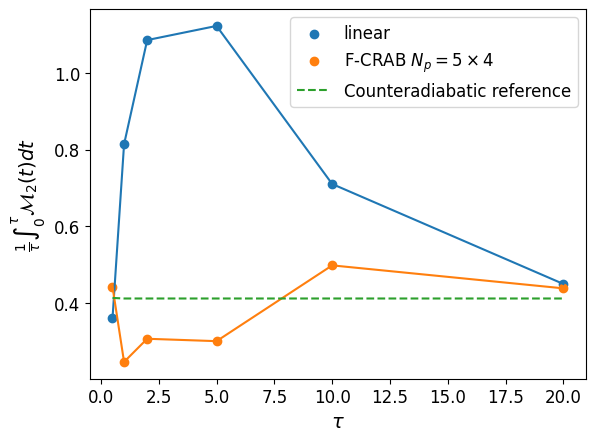

In [9]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

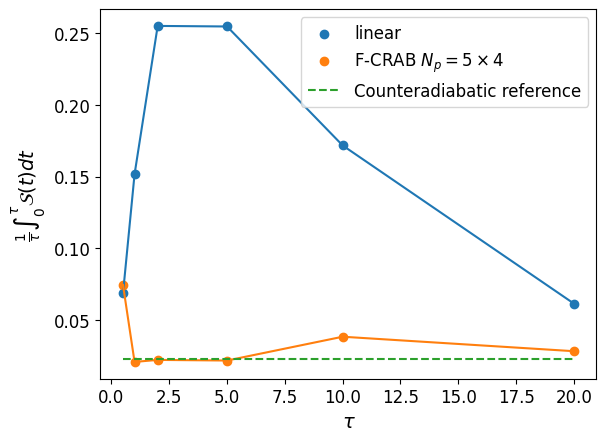

In [10]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()